In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [9]:
df = pd.read_csv("/kaggle/input/datasets/vaibhavkumar11/hindi-english-parallel-corpus/hindi_english_parallel.csv")

In [10]:
df.isnull().sum()

hindi      6057
english     877
dtype: int64

In [11]:
df = df.dropna()
df = df.drop_duplicates()
print(df.shape)

(1353877, 2)


In [12]:
# Using the full ~100k sample like before. If training is slow, drop this to e.g. 40000
df = df.sample(n=200000, random_state=42).reset_index(drop=True)

## Text Cleaning

In [13]:
def clean_english(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_hindi(text):
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^\u0900-\u097F0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['english'] = df['english'].apply(clean_english)
df['hindi'] = df['hindi'].apply(clean_hindi)

# drop any rows that became empty after cleaning
df = df[(df['english'].str.len() > 0) & (df['hindi'].str.len() > 0)].reset_index(drop=True)

df['hindi'] = "<start> " + df['hindi'] + " <end>"
df[['english', 'hindi']].sample(5, random_state=42)

,english,hindi
59796,go to him and say we are both messengers from ...,<start> अतः जाओ उसके पास और कहो हम तेरे रब के ...
51749,export r syntax file,<start> निर्यात आर वाक्यविन्यास फ़ाइल <end>
133860,and who is more unjust than those who forbid t...,<start> और उससे बढ़कर ज़ालिम कौन होगा जो खुदा ...
99202,is there sickness in their hearts or are they ...,<start> क्या उनके दिलों में रोग है या वे सन्दे...
104982,beholdest thou not that allah driveth a cloud ...,<start> क्या तुमने देखा नहीं कि अल्लाह बादल को...


##  Tokenization & padding

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000

english_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
hindi_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>", filters="")

english_tokenizer.fit_on_texts(df['english'])
hindi_tokenizer.fit_on_texts(df['hindi'])

english_sequence = english_tokenizer.texts_to_sequences(df['english'])
hindi_sequence = hindi_tokenizer.texts_to_sequences(df['hindi'])

In [15]:
english_sequence_len = [len(seq) for seq in english_sequence]
hindi_sequence_len = [len(seq) for seq in hindi_sequence]

print("95th percentile english len:", np.percentile(english_sequence_len, 95))
print("95th percentile hindi len:", np.percentile(hindi_sequence_len, 95))

95th percentile english len: 41.0
95th percentile hindi len: 48.0


In [16]:
MAX_ENGLISH_LEN = 41
MAX_HINDI_LEN = 48

english_padded = pad_sequences(english_sequence, maxlen=MAX_ENGLISH_LEN, padding='post', truncating='post')
hindi_padded = pad_sequences(hindi_sequence, maxlen=MAX_HINDI_LEN, padding='post', truncating='post')

print(english_padded.shape, hindi_padded.shape)

(198086, 41) (198086, 48)


In [17]:
ENGLISH_VOCAB_SIZE = min(VOCAB_SIZE, len(english_tokenizer.word_index) + 1)
HINDI_VOCAB_SIZE = min(VOCAB_SIZE, len(hindi_tokenizer.word_index) + 1)
print(ENGLISH_VOCAB_SIZE, HINDI_VOCAB_SIZE)

20000 20000


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(english_padded, hindi_padded, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)

(158468, 41) (19809, 41) (19809, 41)


## Model - Encoder-Decoder with Attention


In [28]:
EMBEDDING_DIM = 128
ENCODER_UNITS = 128
DECODER_UNITS = 256   # = 2 * ENCODER_UNITS, since the encoder is bidirectional and states are concatenated

In [29]:
from tensorflow.keras.layers import (Input, Embedding, Bidirectional, GRU,
                                      Concatenate, Dense, Attention)
from tensorflow.keras.models import Model

# Encoder
encoder_inputs = Input(shape=(MAX_ENGLISH_LEN,), name="encoder_inputs")

encoder_embedding_layer = Embedding(
    input_dim=ENGLISH_VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name="encoder_embedding"
)
encoder_embedded = encoder_embedding_layer(encoder_inputs)

encoder_bigru = Bidirectional(
    GRU(ENCODER_UNITS, return_sequences=True, return_state=True, dropout= 0.2),
    merge_mode="concat",
    name="encoder_bigru"
)
encoder_outputs, forward_state, backward_state = encoder_bigru(encoder_embedded)

encoder_state = Concatenate(name="encoder_state_concat")([forward_state, backward_state])

state_projection = Dense(DECODER_UNITS, activation="tanh", name="state_projection")
encoder_state_proj = state_projection(encoder_state)

encoder_model_summary = Model(encoder_inputs, [encoder_outputs, encoder_state_proj], name="Encoder")
encoder_model_summary.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 41)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 41, 128)   │  2,560,000 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 41)        │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_bigru       │ [(None, 41, 256), │    198,144 │ encoder_embeddin… │
│ (Bidirectional)     │ (None, 128),      │            │ not_equal_2[0][0] │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_state_conc… │ (None, 256)       │          0 │ encoder_bigru[0]… │
│ (Concatenate)       │                   │            │ encoder_bigru[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_projection    │ (None, 256)       │     65,792 │ encoder_state_co… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,823,936 (10.77 MB)

 Trainable params: 2,823,936 (10.77 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Decoder
decoder_inputs = Input(shape=(MAX_HINDI_LEN - 1,), name="decoder_inputs")

decoder_embedding_layer = Embedding(
    input_dim=HINDI_VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name="decoder_embedding"
)
decoder_embedded = decoder_embedding_layer(decoder_inputs)

decoder_gru = GRU(
    DECODER_UNITS,
    return_sequences=True,
    return_state=True,
    name="decoder_gru",
    dropout = 0.2
)
decoder_seq_outputs, decoder_state = decoder_gru(decoder_embedded, initial_state=encoder_state_proj)


attention_layer = Attention(name="attention_layer")
context_vector = attention_layer([decoder_seq_outputs, encoder_outputs])

context_concat_layer = Concatenate(name="context_concat")
decoder_combined = context_concat_layer([decoder_seq_outputs, context_vector])

pre_output_dense = Dense(DECODER_UNITS, activation="tanh", name="pre_output_dense")
decoder_pre_output = pre_output_dense(decoder_combined)

output_layer = Dense(HINDI_VOCAB_SIZE, activation="softmax", name="output_layer")
decoder_outputs = output_layer(decoder_pre_output)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs, name="training_model")
model.summary()

Model: "training_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 41)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 41, 128)   │  2,560,000 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 41)        │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_bigru       │ [(None, 41, 256), │    198,144 │ encoder_embeddin… │
│ (Bidirectional)     │ (None, 128),      │            │ not_equal_2[0][0] │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 47)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_state_conc… │ (None, 256)       │          0 │ encoder_bigru[0]… │
│ (Concatenate)       │                   │            │ encoder_bigru[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 47, 128)   │  2,560,000 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_projection    │ (None, 256)       │     65,792 │ encoder_state_co… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_gru (GRU)   │ [(None, 47, 256), │    296,448 │ decoder_embeddin… │
│                     │ (None, 256)]      │            │ state_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 47, 256)   │          0 │ decoder_gru[0][0… │
│ (Attention)         │                   │            │ encoder_bigru[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_concat      │ (None, 47, 512)   │          0 │ decoder_gru[0][0… │
│ (Concatenate)       │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pre_output_dense    │ (None, 47, 256)   │    131,328 │ context_concat[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 47, 20000) │  5,140,000 │ pre_output_dense… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,951,712 (41.78 MB)

 Trainable params: 10,951,712 (41.78 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Train

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

decoder_input_train = y_train[:, :-1]
decoder_target_train = y_train[:, 1:]

decoder_input_val = y_val[:, :-1]
decoder_target_val = y_val[:, 1:]

checkpoint = ModelCheckpoint(

    "/content/drive/MyDrive/best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,      
    patience=2,      
    min_lr=1e-6,    
    verbose=1        
)

history = model.fit(
    [X_train, decoder_input_train],
    decoder_target_train,
    validation_data=([X_val, decoder_input_val], decoder_target_val),
    epochs=25,
    batch_size=64,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/25
2476/2477 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.1327 - loss: 6.4181
Epoch 1: val_loss improved from None to 5.20363, saving model to /content/drive/MyDrive/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model.keras
2477/2477 ━━━━━━━━━━━━━━━━━━━━ 385s 151ms/step - accuracy: 0.1844 - loss: 5.8392 - val_accuracy: 0.2342 - val_loss: 5.2036 - learning_rate: 0.0010
Epoch 2/25
2476/2477 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.2515 - loss: 4.9695
Epoch 2: val_loss improved from 5.20363 to 4.37711, saving model to /content/drive/MyDrive/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model.keras
2477/2477 ━━━━━━━━━━━━━━━━━━━━ 365s 147ms/step - accuracy: 0.2675 - loss: 4.7748 - val_accuracy: 0.3014 - val_loss: 4.3771 - learning_rate: 0.0010
Epoch 3/25
2476/2477 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.3199 - loss: 4.1412
Epoch 3: val_loss improved from 4.37711 to 3.84273, saving model to /cont

In [20]:
from tensorflow.keras.models import load_model
model = load_model("/kaggle/input/models/dhananjaypatil123/best-model/keras/default/1/best_model.keras")

I0000 00:00:1783332574.332524      82 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783332574.338529      82 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [23]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "/kaggle/working/best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,      
    patience=2,      
    min_lr=1e-6,     
    verbose=1        
)


history = model.fit(
    [X_train, decoder_input_train],
    decoder_target_train,
    validation_data=([X_val, decoder_input_val], decoder_target_val),
    epochs=10, 
    batch_size=64,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/10
2476/2477 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5734 - loss: 1.9479
Epoch 1: val_loss improved from None to 3.19419, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
2477/2477 ━━━━━━━━━━━━━━━━━━━━ 343s 138ms/step - accuracy: 0.5688 - loss: 1.9761 - val_accuracy: 0.4523 - val_loss: 3.1942 - learning_rate: 5.0000e-04
Epoch 2/10
2476/2477 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5791 - loss: 1.9120
Epoch 2: val_loss did not improve from 3.19419
2477/2477 ━━━━━━━━━━━━━━━━━━━━ 345s 139ms/step - accuracy: 0.5732 - loss: 1.9462 - val_accuracy: 0.4520 - val_loss: 3.2078 - learning_rate: 5.0000e-04
Epoch 3/10
2476/2477 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5831 - loss: 1.8842
Epoch 3: val_loss did not improve from 3.19419

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2477/2477 ━━━━━━━━━━━━━━━━━━━━ 345s 139ms/step - accuracy: 0.5770 - loss: 1.9194 - val_accu

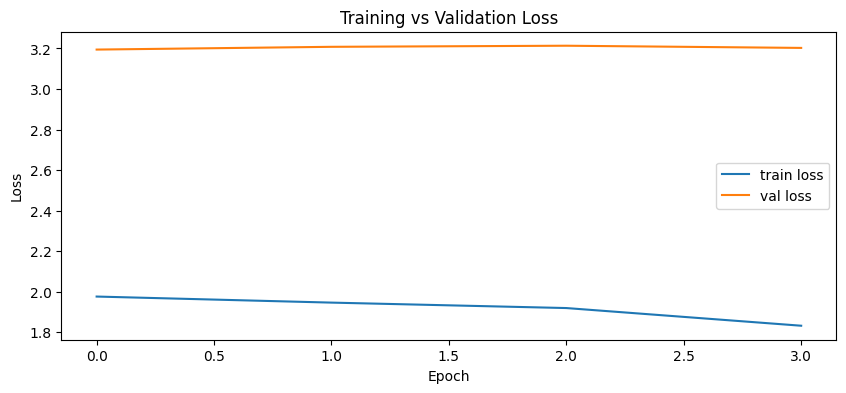

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

## Inference models

In [32]:
model.load_weights("/kaggle/working/best_model.keras")

In [33]:
# Inference Encoder
from tensorflow.keras.models import Model 
from tensorflow.keras.layers import Input
inference_encoder_model = Model(
    encoder_inputs,
    [encoder_outputs, encoder_state_proj],
    name="inference_encoder"
)

#Inference Decoder 
decoder_state_input = Input(shape=(DECODER_UNITS,), name="decoder_state_input")
encoder_outputs_input = Input(shape=(MAX_ENGLISH_LEN, 2 * ENCODER_UNITS), name="encoder_outputs_input")
decoder_input_single = Input(shape=(1,), name="decoder_input_single")

dec_emb_inf = decoder_embedding_layer(decoder_input_single)
dec_seq_out_inf, dec_state_inf = decoder_gru(dec_emb_inf, initial_state=decoder_state_input)

context_inf = attention_layer([dec_seq_out_inf, encoder_outputs_input])
combined_inf = context_concat_layer([dec_seq_out_inf, context_inf])
pre_out_inf = pre_output_dense(combined_inf)
dec_output_inf = output_layer(pre_out_inf)

inference_decoder_model = Model(
    [decoder_input_single, decoder_state_input, encoder_outputs_input],
    [dec_output_inf, dec_state_inf],
    name="inference_decoder"
)

## 8. Translate

In [48]:
def translate(sentence, max_len=MAX_HINDI_LEN, verbose=False):
    cleaned = clean_english(sentence)
    sequence = english_tokenizer.texts_to_sequences([cleaned])
    sequence = pad_sequences(sequence, maxlen=MAX_ENGLISH_LEN, padding="post", truncating="post")

    enc_outputs_val, state_val = inference_encoder_model.predict(sequence, verbose=0)

    current_word = np.array([[hindi_tokenizer.word_index["<start>"]]])
    translated_words = []
    
    
    oov_index = hindi_tokenizer.word_index.get("<OOV>", 1)

    for step in range(max_len):
        prediction, state_val = inference_decoder_model.predict(
            [current_word, state_val, enc_outputs_val],
            verbose=0
        )

        prediction[0, 0, oov_index] = 0.0
        
        predicted_index = int(np.argmax(prediction[0, 0]))
        predicted_word = reverse_hindi_word_index.get(predicted_index, "")

        if verbose:
            print(f"step {step+1}: token={predicted_index} word={predicted_word} "
                  f"confidence={float(np.max(prediction[0, 0])):.3f}")

        if predicted_index == 0 or predicted_word == "<end>":
            break

        translated_words.append(predicted_word)
        current_word = np.array([[predicted_index]])

    return " ".join(translated_words)

In [49]:
print(translate("What is your name?"))

आप कौन है


In [50]:
print(translate("Where are you going?"))

कि आप क्या चल रहा है


In [51]:
print(translate("Good Morning"))

जान बूझकर


In [52]:
print(translate("Hello"))

मोर्चा


In [53]:
idx = 10
print("English:", df['english'].iloc[idx])
print("Hindi (reference):", df['hindi'].iloc[idx])
print("Hindi (predicted):", translate(df['english'].iloc[idx]))

English: the object of translating from english into sanskrit is to gain an accurate literary knowledge of the latter language
Hindi (reference): <start> अंग्रेज़ी से संस्कृत में अनुवाद करने का उद्देश्य है संस्कृत भाषा का सही सही साहित्यिक ज्ञान प्राप्त करना। <end>
Hindi (predicted): संस्कृत में अंग्रेज़ी में अनुवाद करने का उद्देश्य तो इस भाषा का सही साहित्यिक ज्ञान प्राप्त होता है।


In [46]:
words_to_check = ["hello", "morning", "name"]
for w in words_to_check:
    print(f"'{w}' in vocab:", w in english_tokenizer.word_index)

'hello' in vocab: True
'morning' in vocab: True
'name' in vocab: True


In [47]:
for w in words_to_check:
    print(f"'{w}' rank:", english_tokenizer.word_index[w])

'hello' rank: 16397
'morning' rank: 861
'name' rank: 186


In [54]:
print(translate("The government has announced a new policy for agriculture."))

print(translate("This machine is used for industrial manufacturing."))

इसके लिए सरकार ने कृषि के लिए एक नई नीति घोषित की।
यह मशीन औद्योगिक विनिर्माण के लिए किया जाता है।


In [55]:
print("Test 1:", translate("The government has announced a new policy for agriculture."))

print("Test 2:", translate("The mobile application compares hospital pricing and doctor availability."))

print("Test 3:", translate("The global semiconductor manufacturing industry requires advanced microprocessors."))

print("Test 4:", translate("The primary objective is to gain an accurate literary knowledge."))

Test 1: इसके लिए सरकार ने कृषि के लिए एक नई नीति घोषित की।
Test 2: मोबाइल आवेदन की तुलना में तुलना में तुलना और डाक्टर की उपलब्धता
Test 3: यहाँ वैश्विक मंदी विनिर्माण उद्योग की जरूरत है।
Test 4: इसका प्राथमिक उद्देश्य सही साहित्यिक ज्ञान प्राप्त करना है।


In [58]:
import pickle

with open('/kaggle/working/english_tokenizer.pkl', 'wb') as f:
    pickle.dump(english_tokenizer, f)

with open('/kaggle/working/hindi_tokenizer.pkl', 'wb') as f:
    pickle.dump(hindi_tokenizer, f)